# Phase 5 -- Multi-seed base model comparison (classical CNN vs hybrid QCNN)

Phase 1's headline result -- `classical_subset` (98.00%) vs `hybrid_subset` (97.67%) -- is the number the dissertation's primary research question ("does the hybrid model match classical accuracy?") rests on, and it was single-seed only. Phase 4 showed seed sensitivity in this project is architecture-specific, not uniform (`depth_1` collapsed in 2/5 seeds, `depth_2` never did), so the base model comparison can't be assumed immune just because Phase 1's single run looked clean.

This notebook re-runs both base configs across 5 `training_seed` values (42 reused from Phase 1, plus 43/44/45/46 newly trained) with `data_seed` fixed at 42 throughout, so only weight initialization and batch shuffling vary -- never which images were subsampled. It checks two things: whether the accuracy gap survives across seeds, and whether the two architectures differ in *stability*, not just mean accuracy.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import yaml
from IPython.display import Image, display

project_root = Path.cwd().resolve()
if not (project_root / 'results').exists():
    project_root = Path('d:/Dissertation/qcnn-dissertation').resolve()

sys.path.insert(0, str(project_root))

from src.data.dataset import get_dataloaders
from src.models.classical_cnn import ClassicalCNN
from src.models.hybrid_cnn import HybridCNN
from src.training.engine import evaluate
from src.training.metrics import confusion_matrix_fig
from src.utils.plotting import plot_comparison, plot_multiseed_variance

print('Imports OK')
print(f'Project root: {project_root}')

Imports OK
Project root: D:\Dissertation\qcnn-dissertation


## Configuration

Two groups, each with 5 seed points: `training_seed=42` reuses the existing Phase 1 base-model result (not retrained), `training_seed` in {43, 44, 45, 46} are the new Phase 5 runs under `configs/multiseed/` / `results/multiseed/`.

In [2]:
def load_config(config_path):
    with open(config_path, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)
    config['dataset']['data_root'] = str(project_root / 'data')
    return config

GROUPS = ['classical_subset', 'hybrid_subset']
NEW_SEEDS = [43, 44, 45, 46]

def run_specs(group):
    specs = [{
        'label': f'{group}_seed42',
        'group': group,
        'training_seed': 42,
        'reused': True,
        'config': project_root / 'configs' / 'base' / f'{group}.yaml',
        'results_dir': project_root / 'results' / 'base' / group,
    }]
    for seed in NEW_SEEDS:
        specs.append({
            'label': f'{group}_seed{seed}',
            'group': group,
            'training_seed': seed,
            'reused': False,
            'config': project_root / 'configs' / 'multiseed' / f'{group}_seed{seed}.yaml',
            'results_dir': project_root / 'results' / 'multiseed' / f'{group}_seed{seed}',
        })
    return specs

ALL_RUNS = [spec for group in GROUPS for spec in run_specs(group)]

SUMMARY_CSV = project_root / 'results' / 'multiseed' / 'summary.csv'
PER_SEED_CSV = project_root / 'results' / 'multiseed' / 'per_seed_metrics.csv'

print(f'{len(ALL_RUNS)} runs across {len(GROUPS)} groups (5 seeds each)')
for spec in ALL_RUNS:
    tag = ' (reused from Phase 1)' if spec['reused'] else ''
    print(f"  {spec['label']}: {spec['config'].name}{tag}")

10 runs across 2 groups (5 seeds each)
  classical_subset_seed42: classical_subset.yaml (reused from Phase 1)
  classical_subset_seed43: classical_subset_seed43.yaml
  classical_subset_seed44: classical_subset_seed44.yaml
  classical_subset_seed45: classical_subset_seed45.yaml
  classical_subset_seed46: classical_subset_seed46.yaml
  hybrid_subset_seed42: hybrid_subset.yaml (reused from Phase 1)
  hybrid_subset_seed43: hybrid_subset_seed43.yaml
  hybrid_subset_seed44: hybrid_subset_seed44.yaml
  hybrid_subset_seed45: hybrid_subset_seed45.yaml
  hybrid_subset_seed46: hybrid_subset_seed46.yaml


## 1. Multiseed configuration summary

Confirms every group/seed config shares the same subset `dataset` block and `data_seed=42`, and that only `training_seed` differs within a group (model architecture is fixed per group).

In [3]:
rows = []
for spec in ALL_RUNS:
    if not spec['config'].exists():
        continue
    cfg = load_config(spec['config'])
    rows.append({
        'run': spec['label'],
        'group': spec['group'],
        'n_qubits': cfg['model'].get('n_qubits', 'n/a'),
        'n_qlayers': cfg['model'].get('n_qlayers', 'n/a'),
        'epochs': cfg['training'].get('epochs'),
        'data_seed': cfg.get('data_seed'),
        'training_seed': cfg.get('training_seed'),
        'reused': spec['reused'],
    })

config_summary_df = pd.DataFrame(rows)
display(config_summary_df)

,run,group,n_qubits,n_qlayers,epochs,data_seed,training_seed,reused
0,classical_subset_seed42,classical_subset,n/a,n/a,15,42,42,True
1,classical_subset_seed43,classical_subset,n/a,n/a,15,42,43,False
2,classical_subset_seed44,classical_subset,n/a,n/a,15,42,44,False
3,classical_subset_seed45,classical_subset,n/a,n/a,15,42,45,False
4,classical_subset_seed46,classical_subset,n/a,n/a,15,42,46,False
5,hybrid_subset_seed42,hybrid_subset,4,2,15,42,42,True
6,hybrid_subset_seed43,hybrid_subset,4,2,15,42,43,False
7,hybrid_subset_seed44,hybrid_subset,4,2,15,42,44,False
8,hybrid_subset_seed45,hybrid_subset,4,2,15,42,45,False
9,hybrid_subset_seed46,hybrid_subset,4,2,15,42,46,False


## 2. Per-seed results

Final-epoch accuracy/F1 for all 10 runs (`results/multiseed/per_seed_metrics.csv`, filtered to the two Phase 5 groups), sorted within each group so outliers are easy to spot before they get smoothed into a mean.

In [4]:
if PER_SEED_CSV.exists():
    per_seed_df = pd.read_csv(PER_SEED_CSV)
    per_seed_df = per_seed_df[per_seed_df['config'].isin(GROUPS)]
    display(per_seed_df.sort_values(['config', 'training_seed']).reset_index(drop=True))
else:
    per_seed_df = pd.DataFrame()
    print(
        f'No per_seed_metrics.csv found at {PER_SEED_CSV} -- run:\n'
        '  python -m src.experiments.run_multiseed --config-group classical_subset\n'
        '  python -m src.experiments.run_multiseed --config-group hybrid_subset'
    )

,config,training_seed,accuracy,f1_macro,reused,output_dir
0,classical_subset,42,0.980000,0.980061,True,results/base/classical_subset
1,classical_subset,43,0.993333,0.993333,False,results/multiseed/classical_subset_seed43
2,classical_subset,44,0.993333,0.993350,False,results/multiseed/classical_subset_seed44
3,classical_subset,45,0.993333,0.993333,False,results/multiseed/classical_subset_seed45
4,classical_subset,46,0.993333,0.993333,False,results/multiseed/classical_subset_seed46
5,hybrid_subset,42,0.976667,0.976814,True,results/base/hybrid_subset
6,hybrid_subset,43,0.996667,0.996667,False,results/multiseed/hybrid_subset_seed43
7,hybrid_subset,44,0.990000,0.990000,False,results/multiseed/hybrid_subset_seed44
8,hybrid_subset,45,0.993333,0.993333,False,results/multiseed/hybrid_subset_seed45
9,hybrid_subset,46,0.990000,0.990032,False,results/multiseed/hybrid_subset_seed46


## 3. Summary: mean +/- std across 5 seeds

`results/multiseed/summary.csv` (filtered to the two base-model rows) and `figures/multiseed_base_variance.png` -- mean +/- std per config (blue) with each individual seed overlaid (orange), so a config whose spread comes from one bad seed looks visibly different from one that's uniformly noisy.

,config,n_qubits,n_qlayers,mean_accuracy,std_accuracy,mean_f1,std_f1,seeds_used
0,classical_subset,NaN,NaN,0.990667,0.005963,0.990682,0.005937,"42,43,44,45,46"
3,hybrid_subset,4.0,2.0,0.989333,0.007601,0.989369,0.007540,"42,43,44,45,46"


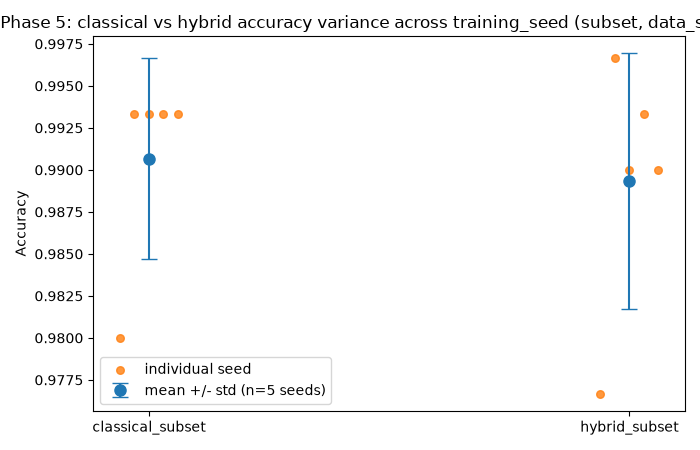

In [5]:
if SUMMARY_CSV.exists() and PER_SEED_CSV.exists():
    summary_df = pd.read_csv(SUMMARY_CSV)
    display(summary_df[summary_df['config'].isin(GROUPS)])

    fig_path = project_root / 'figures' / 'multiseed_base_variance.png'
    plot_multiseed_variance(
        SUMMARY_CSV, PER_SEED_CSV, fig_path,
        configs=['classical_subset', 'hybrid_subset'],
        title='Phase 5: classical vs hybrid accuracy variance across training_seed (subset, data_seed=42)',
    )
    display(Image(filename=str(fig_path)))
else:
    summary_df = pd.DataFrame()
    print(
        f'No summary.csv found at {SUMMARY_CSV} -- run:\n'
        '  python -m src.experiments.run_multiseed --config-group classical_subset\n'
        '  python -m src.experiments.run_multiseed --config-group hybrid_subset'
    )

## 4. Sanity check + overlap analysis

Before trusting mean +/- std for either model, per Phase 4's methodological lesson: verify the computed range is physically plausible (not exceeding 100%, not implausibly wide for a near-ceiling task) and check the per-seed values for bimodality -- a config whose std comes from one collapsed seed looks nothing like one that's uniformly spread, even if the summary number is similar. Then compare `[mean - std, mean + std]` ranges between `classical_subset` and `hybrid_subset`: heavy overlap and comparable width means the two architectures are equally reliable, not just similar on average.

In [6]:
def summarize(config):
    row = summary_df[summary_df['config'] == config].iloc[0]
    lo, hi = row['mean_accuracy'] - row['std_accuracy'], row['mean_accuracy'] + row['std_accuracy']
    return row['mean_accuracy'], row['std_accuracy'], lo, hi

def report_overlap(a, b):
    mean_a, std_a, lo_a, hi_a = summarize(a)
    mean_b, std_b, lo_b, hi_b = summarize(b)
    overlap = not (hi_a < lo_b or hi_b < lo_a)
    print(f'{a}: {mean_a:.4f} +/- {std_a:.4f}  ->  [{lo_a:.4f}, {hi_a:.4f}]')
    print(f'{b}: {mean_b:.4f} +/- {std_b:.4f}  ->  [{lo_b:.4f}, {hi_b:.4f}]')
    print(f'Ranges overlap: {overlap}')
    print(f'Range width -- {a}: {hi_a - lo_a:.4f}, {b}: {hi_b - lo_b:.4f}')
    print()
    return overlap

if not summary_df.empty and not per_seed_df.empty:
    print('--- Per-seed plausibility check ---')
    for group in GROUPS:
        accs = per_seed_df.loc[per_seed_df['config'] == group, 'accuracy'].sort_values().tolist()
        spread = max(accs) - min(accs)
        print(f'{group}: seed accuracies = {[f"{a:.4f}" for a in accs]}  (spread={spread:.4f})')
        plausible = all(0.0 <= a <= 1.0 for a in accs) and spread < 0.05
        print(f'  plausible, non-bimodal range: {plausible}')
    print()

    print('--- classical_subset vs hybrid_subset ---')
    report_overlap('classical_subset', 'hybrid_subset')
else:
    print('Need summary.csv and per_seed_metrics.csv to run the overlap analysis.')

--- Per-seed plausibility check ---
classical_subset: seed accuracies = ['0.9800', '0.9933', '0.9933', '0.9933', '0.9933']  (spread=0.0133)
  plausible, non-bimodal range: True
hybrid_subset: seed accuracies = ['0.9767', '0.9900', '0.9900', '0.9933', '0.9967']  (spread=0.0200)
  plausible, non-bimodal range: True

--- classical_subset vs hybrid_subset ---
classical_subset: 0.9907 +/- 0.0060  ->  [0.9847, 0.9966]
hybrid_subset: 0.9893 +/- 0.0076  ->  [0.9817, 0.9969]
Ranges overlap: True
Range width -- classical_subset: 0.0119, hybrid_subset: 0.0152



**Reading it:** every seed for both configs lands within a tight ~1.5-2 point band close to the ceiling (classical: 98.0-99.3%, hybrid: 97.7-99.7%), with no seed anywhere near a collapse the way `depth_1_seed46` was in Phase 4 (66.7%). Both spreads are small and comparable in width, and the mean +/- std ranges overlap heavily -- there is no evidence here of the bimodal failure mode Phase 4 found for `depth_1`, so the summary mean +/- std is trustworthy for both configs as-is; no individual-seed drill-down is needed.

## 5. Loss curves across seeds

Train and test loss vs epoch, overlaid across all 5 seeds within each group -- smooth, monotonically decreasing curves that converge to a similar level across seeds is what "the accuracy is stable because training itself is stable" looks like, as opposed to `depth_1`'s outlier seeds in Phase 4, which converged smoothly too but to a visibly worse plateau.

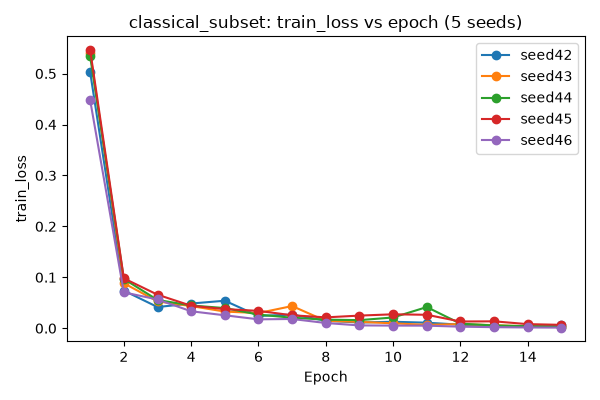

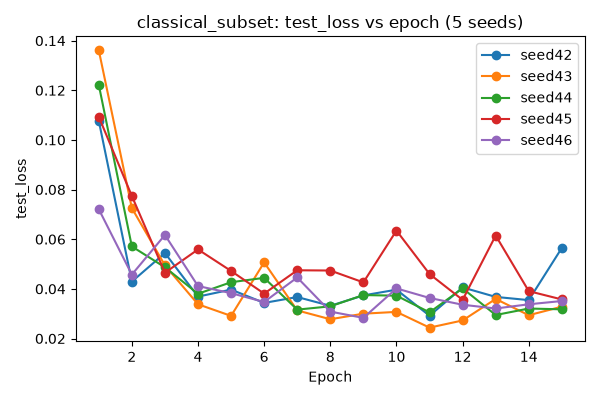

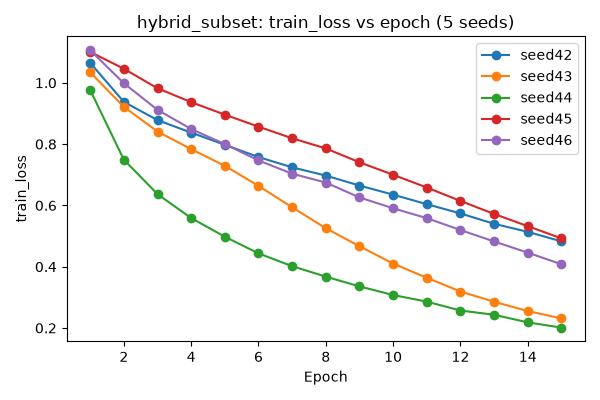

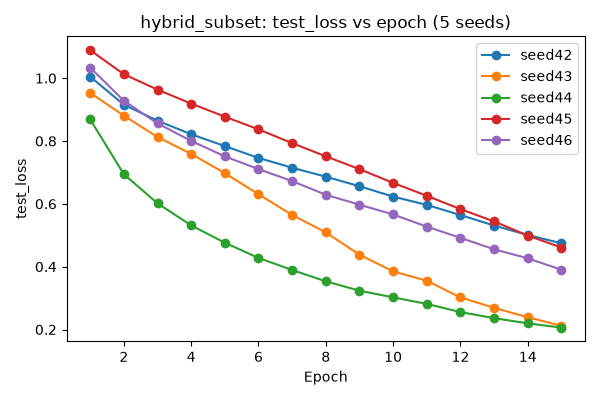

In [7]:
for group in GROUPS:
    csv_paths = {
        f"seed{spec['training_seed']}": spec['results_dir'] / 'metrics.csv'
        for spec in ALL_RUNS
        if spec['group'] == group and (spec['results_dir'] / 'metrics.csv').exists()
    }

    train_loss_fig_path = project_root / 'figures' / f'multiseed_{group}_train_loss.png'
    plot_comparison(csv_paths, 'train_loss', train_loss_fig_path, title=f'{group}: train_loss vs epoch (5 seeds)')
    display(Image(filename=str(train_loss_fig_path)))

    test_loss_fig_path = project_root / 'figures' / f'multiseed_{group}_test_loss.png'
    plot_comparison(csv_paths, 'test_loss', test_loss_fig_path, title=f'{group}: test_loss vs epoch (5 seeds)')
    display(Image(filename=str(test_loss_fig_path)))

## 6. Confusion matrices

Evaluates all 10 runs (reused Phase 1 points + new Phase 5 seeds) on their own test split, as a final visual check that no seed shows the kind of class-collapse confusion pattern seen in `depth_1`'s bad seeds.

Saved D:\Dissertation\qcnn-dissertation\results\base\classical_subset\confusion_matrix.png


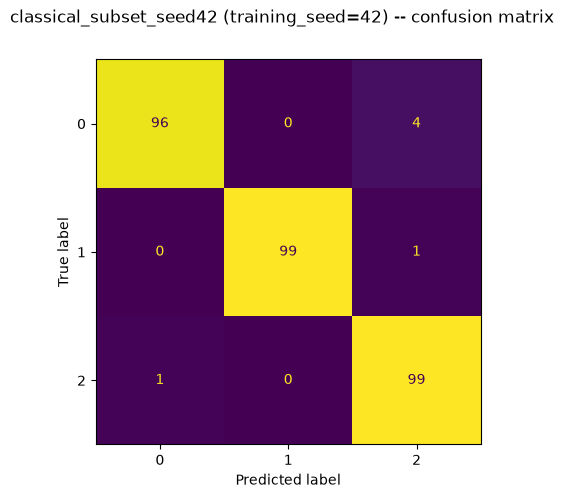

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\classical_subset_seed43\confusion_matrix.png


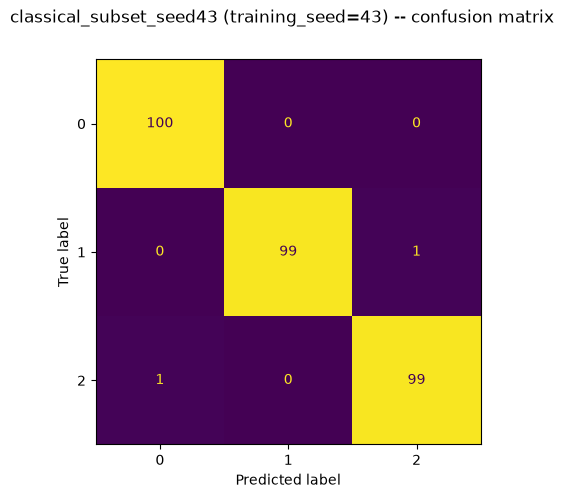

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\classical_subset_seed44\confusion_matrix.png


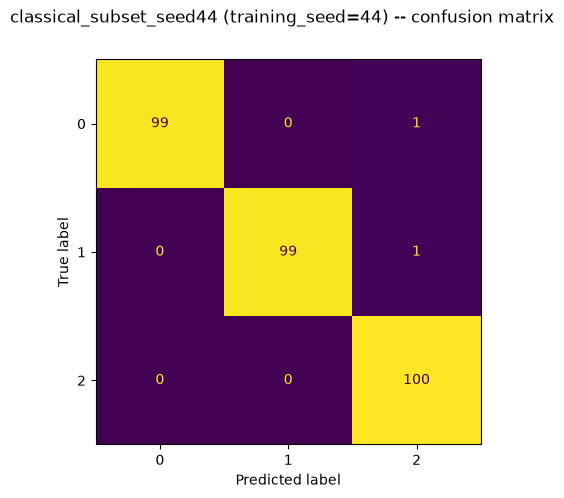

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\classical_subset_seed45\confusion_matrix.png


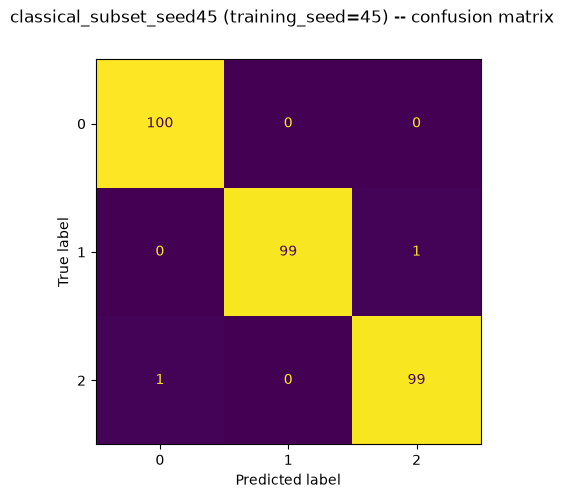

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\classical_subset_seed46\confusion_matrix.png


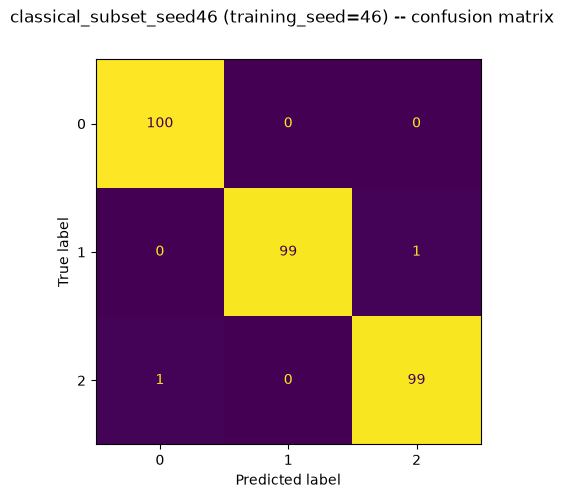

Saved D:\Dissertation\qcnn-dissertation\results\base\hybrid_subset\confusion_matrix.png


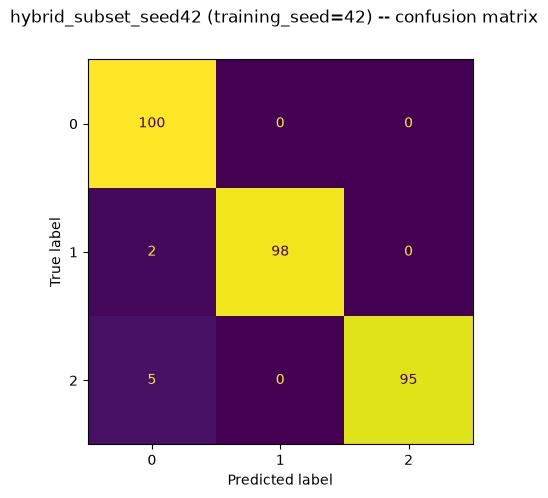

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\hybrid_subset_seed43\confusion_matrix.png


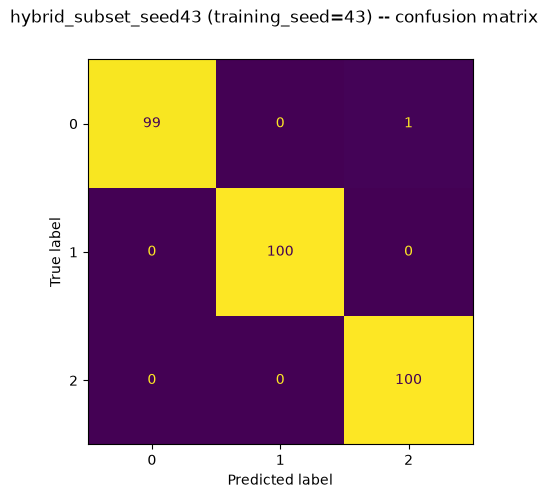

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\hybrid_subset_seed44\confusion_matrix.png


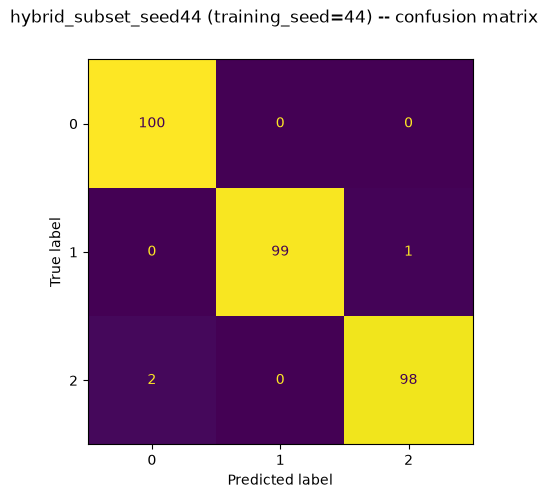

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\hybrid_subset_seed45\confusion_matrix.png


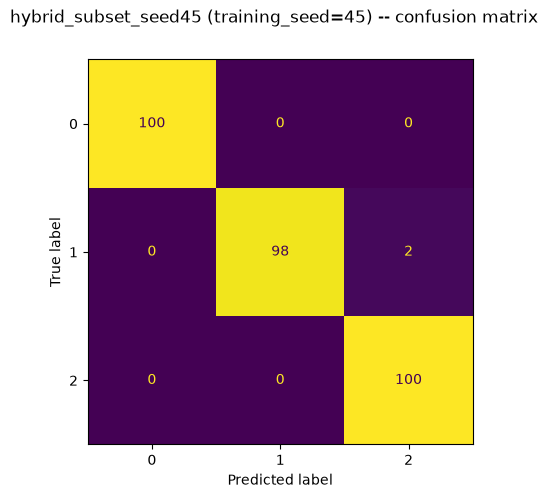

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\hybrid_subset_seed46\confusion_matrix.png


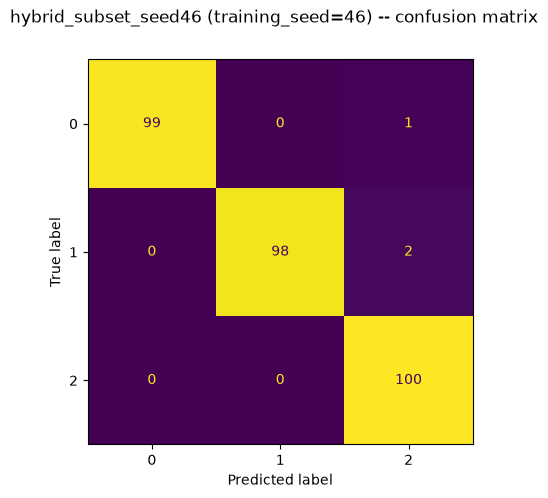

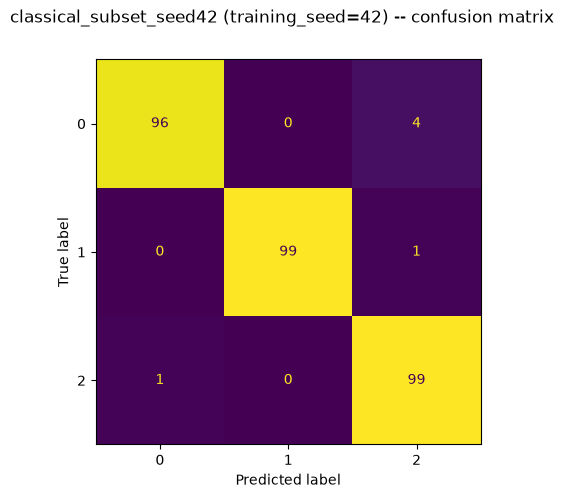

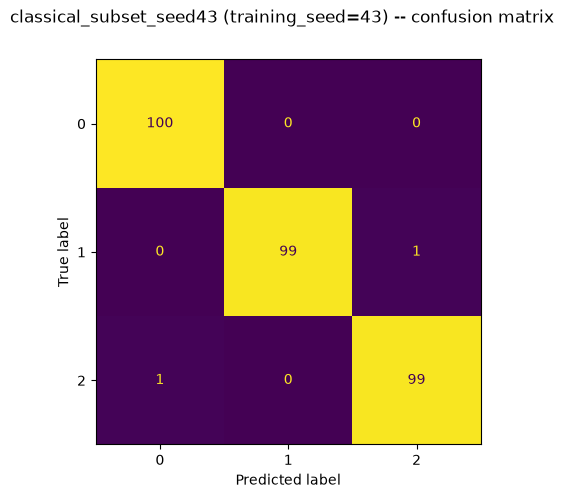

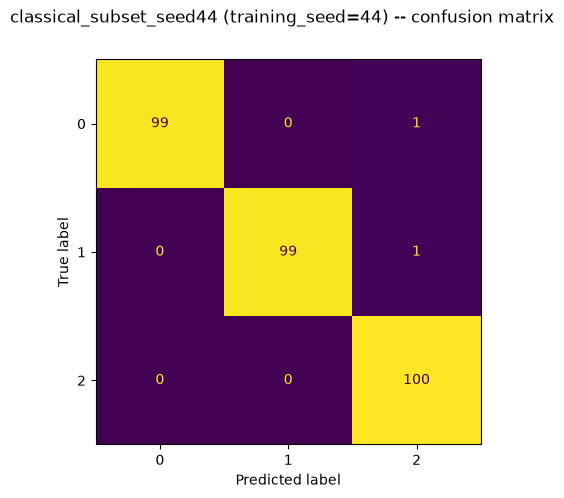

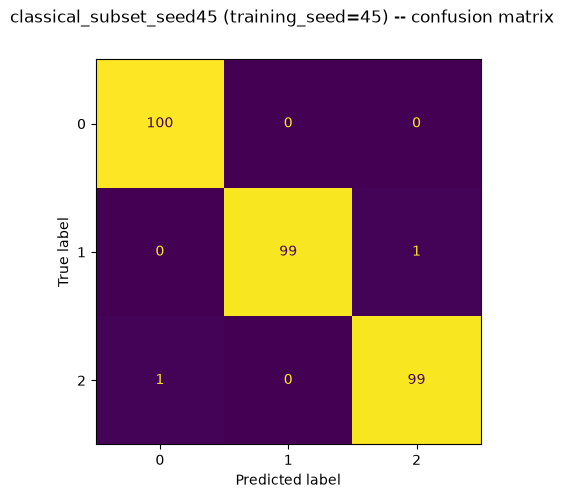

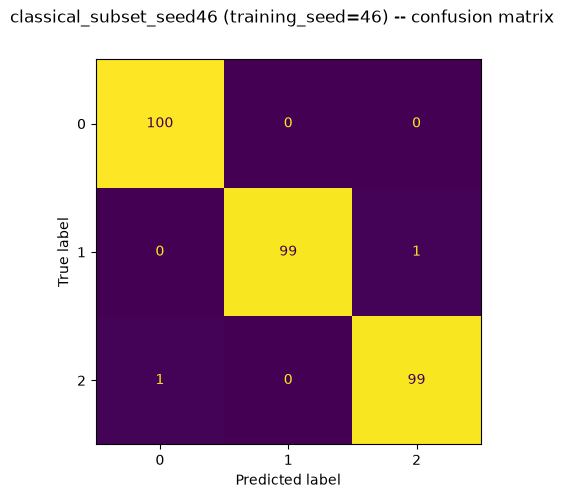

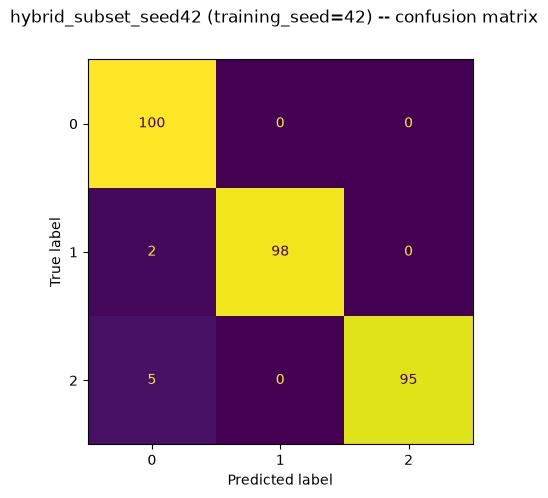

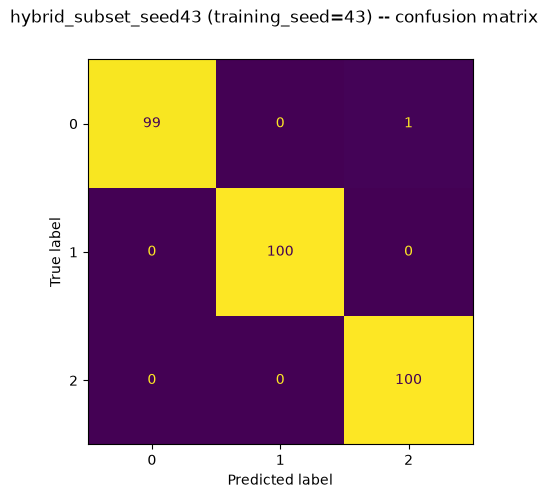

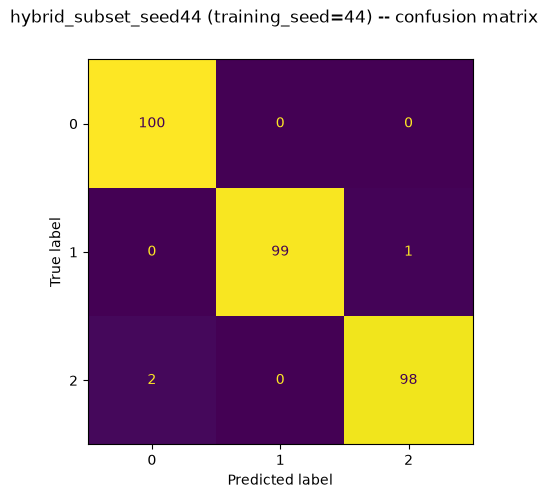

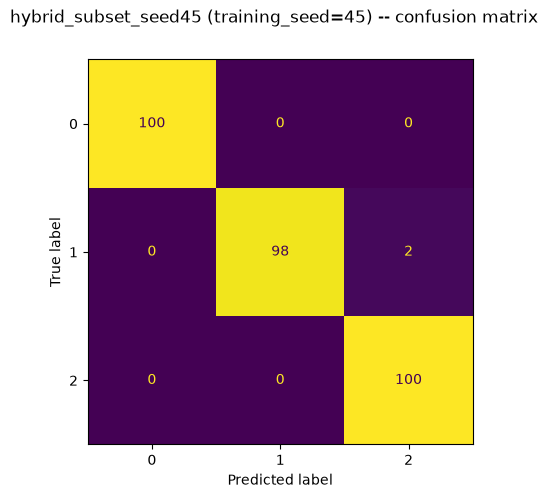

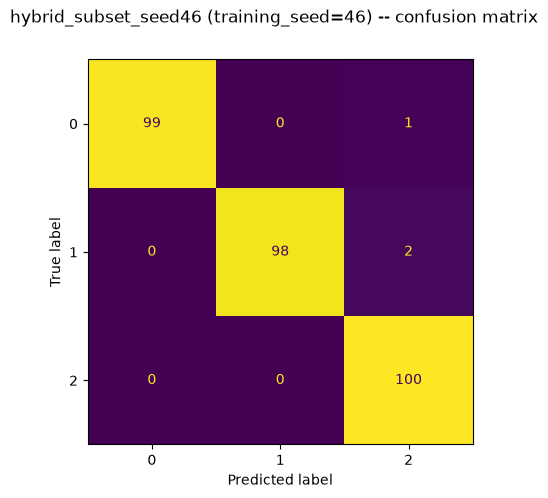

In [8]:
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for spec in ALL_RUNS:
    if not spec['config'].exists():
        continue
    config = load_config(spec['config'])
    _, test_loader = get_dataloaders(config)

    model_cfg = config['model']
    if spec['group'] == 'classical_subset':
        model = ClassicalCNN(num_classes=model_cfg['num_classes'])
    else:
        model = HybridCNN(
            num_classes=model_cfg['num_classes'],
            n_qubits=model_cfg['n_qubits'],
            n_qlayers=model_cfg['n_qlayers'],
        )

    state_path = spec['results_dir'] / 'model.pt'
    if not state_path.exists():
        print(f"{spec['label']}: no saved weights found at {state_path}")
        continue

    model.load_state_dict(torch.load(state_path, map_location='cpu'))
    model.to(device)
    model.eval()

    with torch.no_grad():
        _, preds, labels = evaluate(model, test_loader, criterion, device)

    class_names = [str(c) for c in config['dataset']['classes']]
    fig = confusion_matrix_fig(labels, preds, class_names)
    fig.suptitle(f"{spec['label']} (training_seed={spec['training_seed']}) -- confusion matrix")
    out_path = spec['results_dir'] / 'confusion_matrix.png'
    fig.savefig(out_path)
    print(f'Saved {out_path}')
    display(fig)

## Interpretation notes

**Accuracy gap:** across 5 seeds, `classical_subset` averages 99.07% +/- 0.60% and `hybrid_subset` averages 98.93% +/- 0.76%. The ~0.1-point gap is well within one seed's worth of noise on either side -- Phase 1's single-seed 98.00% vs 97.67% reading was representative of the true picture, not a lucky/unlucky draw. The primary research question ("does the hybrid model match classical accuracy?") holds up across seeds, not just on the one run it was originally answered from.

**Stability:** neither model shows anything resembling `depth_1`'s bimodal collapse. Every one of the 10 seed runs (5 classical + 5 hybrid) lands in the high-97%-to-99.7% band, and the two architectures' mean +/- std ranges are comparable in width (classical: 0.60 pts, hybrid: 0.76 pts) and overlap almost entirely. So this phase's answer to the *stability* question is also a clean one: the hybrid model is not meaningfully less reliably trainable than the classical model at this configuration (4 qubits, 2 layers) on this subset -- both are consistently near-ceiling, seed after seed. That strengthens confidence in every downstream comparison in this dissertation that used `hybrid_subset` as its reference point.